### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube
import time
%matplotlib inline   

In [2]:
start_time=time.time()

#### Schematic representation of the architecture

![image](./rfi_framework.png)

### Read FM Transmitter Database 

In [3]:
n = str(input("Enter the number of countries to include"))

Enter the number of countries to includeAll


In [4]:
df = read_database.read_FM_database(countries=read_database.get_countries(n))

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)


### Define frequency range  

In [5]:
freq_range = read_database.get_freq_range()

Please enter the minimum value of the frequency range (in MHz): 55
Please enter the maximum value of the frequency range (in MHz): 110
Please enter the resolution of the frequency (in MHz): 0.244


In [6]:
df = read_database.extract_common_freq(df, freq_range)


### Define resolution of the Healpy map

In [7]:
print('----------- Resolution of the map -----------')

# The default value of nside is 16
nside = int(input("Enter the NSIDE of the healpy map"))
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

----------- Resolution of the map -----------
Enter the NSIDE of the healpy map32
The number of pixels for the given NSIDE: 12288
Approximate resolution in degrees for given nside 1.83
Pixel area: 3.36 square degrees


In [8]:
beam_pattern=str(input('Enter desired beam pattern:'))

Enter desired beam pattern:sin square


### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [9]:
df, pixel_indices = read_database.allocate_pixel_num(nside, df)


### Define altitude of the satellite orbit 

In [10]:
altitudes = satellite_properties.get_altitudes()

Enter the minimum altitude of the satellite: 400
Enter the maximum altitude of the satellite: 36000
Enter number of data points : 3


### Calculation of Elevation angle

In [11]:
elev_angle = satellite_properties.calc_elev_angle(npix, phi, theta, altitudes)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:43: RuntimeWarning: divide by zero encountered in scalar divide
  elev_ang[k,i,j]=-(np.degrees(np.arctan((B-np.cos(np.radians(y_ang[i,j])))/np.sin(np.radians(y_ang[i,j])))))
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:41: RuntimeWarning: invalid value encountered in arccos
  y_ang[i,j]=(np.arccos(x_ang[i,j]))


### Define radiation pattern of the satellite antenna beam [optional]

In [12]:
np.shape(elev_angle)

(3, 12288, 12288)

In [13]:
beam = satellite_properties.get_beam_pattern("sin square", theta)
az = 0 # Assuming the satellite antenna beam to be symmetric across azimuth

###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [14]:
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 400.00 km is 2.45 radians
The Field of view of the satellite at a height of 3794.73 km is 1.36 radians
The Field of view of the satellite at a height of 36000.00 km is 0.30 radians


In [15]:
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)

The Radius of the Field of View for a height of 400.00 km in radians is 0.35
The Radius of the Field of View for a height of 3794.73 km in radians is 0.89
The Radius of the Field of View for a height of 36000.00 km in radians is 1.42


# Create power cube 

In [16]:
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)

In [17]:
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)

In [18]:
found_common = store_FOV_indices.get_common_Tx(pixel_indices, pix_common, Rad_of_FOV)

## Plot Healpy map of beam-weighted FOV of a satellite overhead a particular location

<b> Transmitter locations from the FM Transmitter database and the received power at different altitudes has not been taken into account for these plots <b>

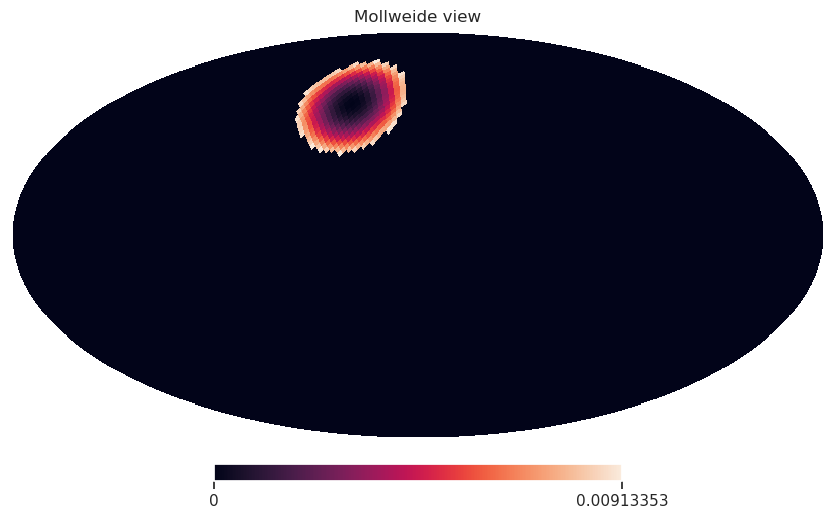

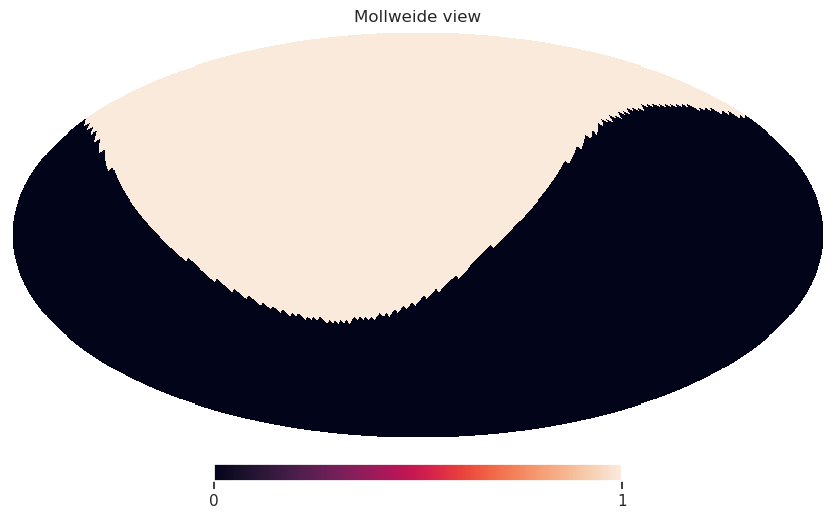

In [19]:
i=1500
xx4=disc[i][0]  # For Hanle at an altitude of 400 km
xx5=disc[686][1]
xx6=disc[i][2]

y4=satellite_properties.get_beam_pattern("cos square", elev_angle[0,i,xx4])
y5=satellite_properties.get_beam_pattern("cos square", elev_angle[1,686,xx5])
y6=satellite_properties.get_beam_pattern("sin square", elev_angle[2,i,xx6])

data4= np.zeros(hp.nside2npix(nside))
data5= np.zeros(hp.nside2npix(nside))
data6= np.zeros(hp.nside2npix(nside))

data4[xx4]=y4
data5[xx5]=y5

data6[xx6]=y6

hp.mollview(data4,flip='geo')
# hp.mollview(data5,flip='geo')
hp.mollview(data6,flip='geo')

In [20]:
Rx_Power_in_Kelvin = Friis.calc_Friis(df, altitudes)[2]
# print(df)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:30: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBm[j][i]= 10.*np.log10( Rx_Power[j][i])+30
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:32: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBW[j][i]= 10.*np.log10( Rx_Power[j][i])


In [21]:
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle,beam_pattern)

In [22]:
power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)

In [23]:
end_time=time.time()

## Plot  Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

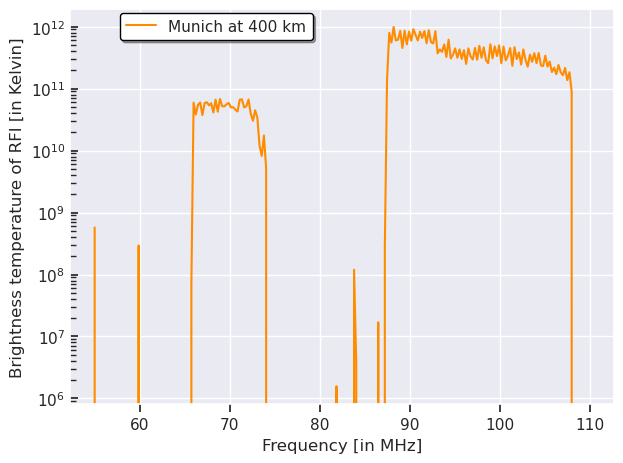

In [24]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
munpix=hp.ang2pix(nside, 11.580224258292716,48.13469781361046,lonlat=True)
plt.plot(freq_range,power_output[0,munpix,:], label='Munich at 400 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Munich_36000_new.pdf")

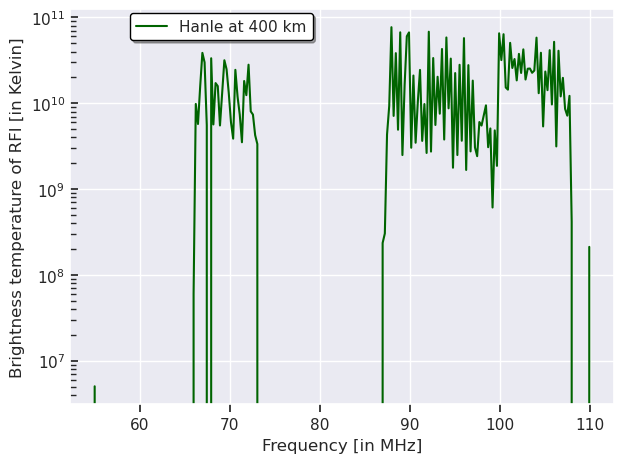

In [25]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
hanlepix=hp.ang2pix(nside, 79.00064650939689,32.79063979504319,lonlat=True)
plt.plot(freq_range,power_output[0,hanlepix,:], label='Hanle at 400 km', color='darkgreen') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Hanle_36000_new.pdf")

In [26]:
num_of_rfi_chan=len(freq_range[power_output[0,13,:]!=0])
num_of_rfi_chan


#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=3 (Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Pacic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)




#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)





#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)







#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#NUM_OF_RFI_CHANNEL=13 (Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany)






#NUM_OF_RFI_CHANNEL=32 (Arctic Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=12 (Arctic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA)

#NUM_OF_RFI_CHANNEL=12 (Pacific Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=2 (Paciic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA)




#NUM_OF_RFI_CHANNEL=31 (Arctic Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=11 (Arctic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo)

#NUM_OF_RFI_CHANNEL=10 (Pacific Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0(Paciic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo)




114

In [27]:
rfi_band=244*num_of_rfi_chan # in kHz
rfi_band_inMHz=rfi_band*1e-3
rfi_band_inMHz

27.816

In [28]:
tot_band=freq_range[-1]-freq_range[0]
usable_band=tot_band-rfi_band_inMHz
usable_band


#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia )
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia 
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)




#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, 
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, )






#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA,, Germany)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#USABLE_BW=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#USABLE_BW_CHANNEL=54.268(Pacifc Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany)





#USABLE_BW=47.192(Arctic Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=52.072 (Arctic Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA)

#USABLE_BW=52.072(Pacific Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=54.512(Pacifc Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA)





#USABLE_BW=47.436(Arctic Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=52.316 (Arctic Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo)

#USABLE_BW=52.56(Pacific Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=55(Pacifc Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo)



27.08399999999995

In [29]:
time=1
FOM=time*usable_band
FOM

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 55.0
#---------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia )34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia ) 55

#------------------------------------------------------------------------------------------------------------



#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada ) 55

#---------------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.50
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany) 53.048


#FOM=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany) 55

#---------------------------------------------------------------------------------------------------------------


#FOM=47.192(Arctic Ocean at 36000 km (Tokyo, USA,) 31.576
#FOM=52.072(Arctic Ocean at 3795 km (Tokyo, USA) 34.992
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA) 53.048


#FOM=52.072(Pacific Ocean at 36000 km (Tokyo, USA) 34.748
#FOM=54.512(Paciic Ocean at 3795 km (Tokyo, USA )34.748
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA) 55

#------------------------------------------------------------------------------------------------------------


#FOM=47.436(Arctic Ocean at 36000 km (Tokyo,) 47.192
#FOM=52.316(Arctic Ocean at 3795 km (Tokyo) 52.316
#FOM=55(Arctic Ocean at 400 km (Tokyo) 55


#FOM=52.56(Pacific Ocean at 36000 km (Tokyo) 52.316
#FOM=55(Paciic Ocean at 3795 km (Tokyo ) 54.756
#FOM=55(Pacific Ocean at 400 km (Tokyo) 55

27.08399999999995

In [294]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

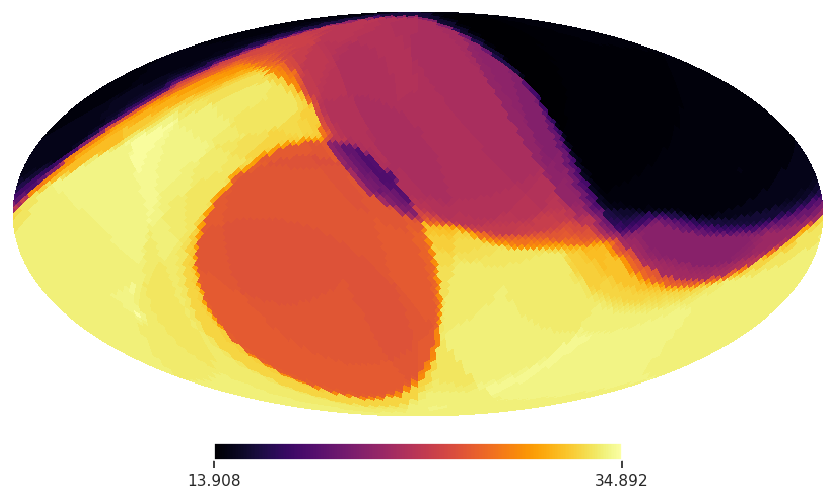

In [295]:

hp.mollview(FOM_map,flip='geo',cmap='inferno',title='')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/FOM_map.pdf',dpi=600)

In [32]:
good_spots=np.where(FOM_map==max(FOM_map))

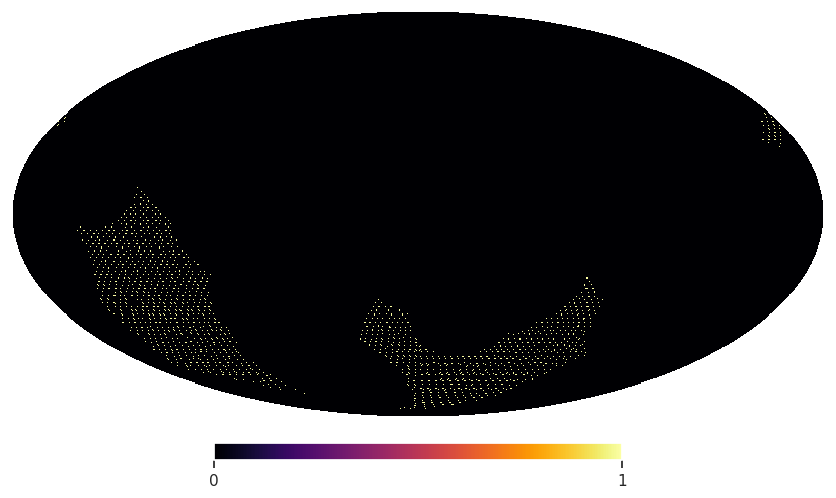

In [34]:
from src2.shapecheck import shapecheck
goodlon,goodlat=hp.pix2ang(nside,good_spots,lonlat=True)
shapecheck(goodlon,goodlat,'')


In [35]:
np.max(FOM_map)

54.89999999999995

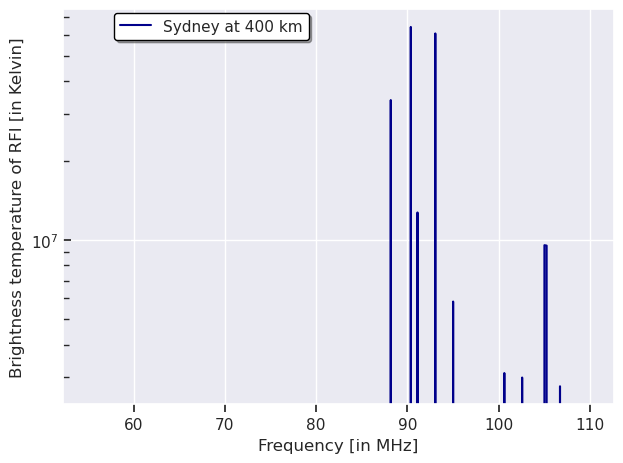

In [264]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
pix_req=hp.ang2pix(nside,-10,-25,lonlat=True)
plt.plot(freq_range,power_output[0,pix_req,:], label='Sydney at 400 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)

# plt.savefig("/home/sonia/Documents/RFI_PAPER/Sydney_400_new.pdf")

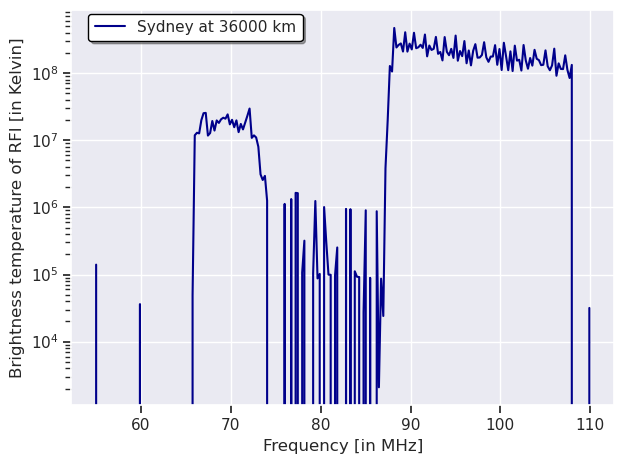

In [37]:
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})

plt.plot(freq_range,power_output[2,2363,:], label='Sydney at 36000 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.44, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Sydney_36000_new.pdf")

## Optimal orbit RFI 

In [317]:
pratushfreq=200
test_plot = np.zeros(hp.nside2npix(nside))
test_plot[0:np.size(power_output[0,:,100])] = power_output[0,:,pratushfreq]

In [318]:
dff=pd.read_csv('/home/saurabhs/Documents/Yogen_starfire/neworbit.csv')
Lon=dff['Lon'].to_numpy()
Lat=dff['Lat'].to_numpy()

In [319]:
orbitpix=hp.ang2pix(nside,Lon,Lat,lonlat=True)

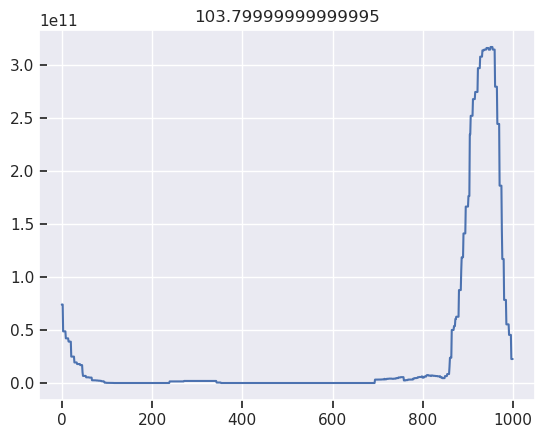

In [320]:
plt.plot(range(len(pix)),test_plot[pix])
plt.title(str(freq_range[pratushfreq]))
plt.show()

In [321]:
hp.pix2ang(nside,orbitpix[50],lonlat=True)

(216.5625, 25.944479772370002)

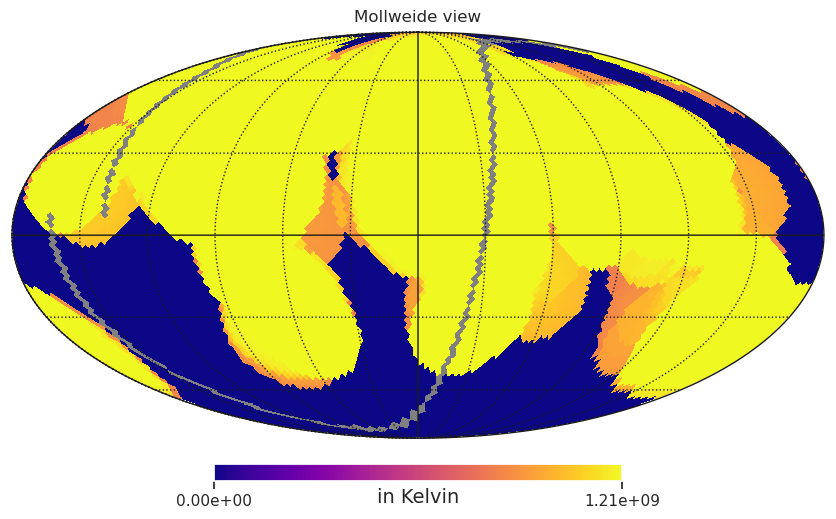

In [322]:
#from healpy.newvisufunc import projview, newprojplot
test_plot[orbitpix]=hp.UNSEEN

hp.mollview(test_plot,cmap='plasma',unit="in Kelvin",flip='geo',norm="hist",format= '%.2e',max=1.21e9)
hp.graticule()
sns.set(font_scale=2)
plt.show()


In [323]:
x=freq_range
y=np.arange(0,len(orbitpix),1)
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(y),len(x)))
for i in range(len(x)):
    for index,j in enumerate(orbitpix):
        power_val[index,i]+=power_output[0,j,i]


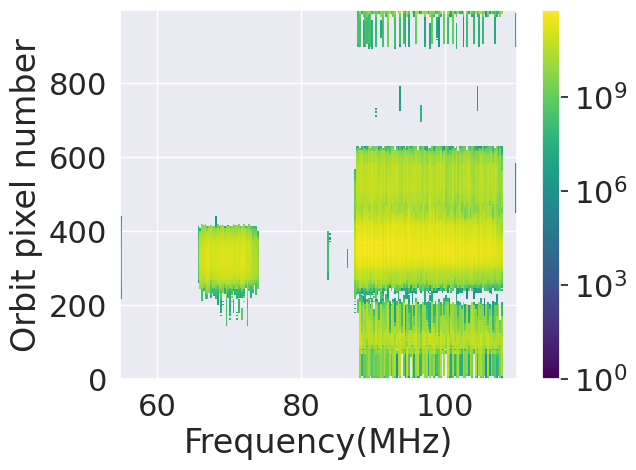

In [324]:
plt.pcolormesh(xx,yy,power_val,cmap='viridis',norm='log',vmin=1,rasterized=True)
plt.xlabel('Frequency(MHz)')
plt.ylabel('Orbit pixel number')
plt.colorbar()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/New_waterfallplot.pdf',bbox_inches='tight',dpi=600)
plt.show()

## FOM values along the orbit

In [325]:
orbitfom=[]
for i in orbitpix:
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	orbitfom.append(usable_band)

In [326]:
orbitfom=np.array(orbitfom)
goodpix=orbitpix[np.where(orbitfom>50)]

(270,)

In [327]:
# quietlon,quietlat=hp.pix2ang(nside,goodpix,lonlat=True)
# quietlon[quietlon>180]-=360
# quietdf=pd.DataFrame({'Lon':quietlon,'Lat':quietlat})
# quietdf.to_csv('/home/saurabhs/Documents/Yogen_starfire/quitpoints.csv')

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (1000,) and arg 2 with shape (226,).

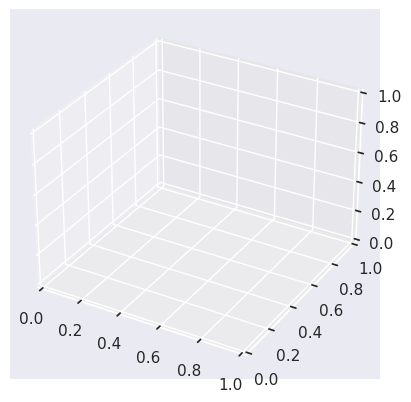

In [291]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = Lon
y = Lat
z = freq_range
c = power_val

img = ax.scatter(x, y, z, c=c, cmap=plt.hot())
fig.colorbar(img)
plt.show()


## Plot Healpy map of brightness temperature of RFI 

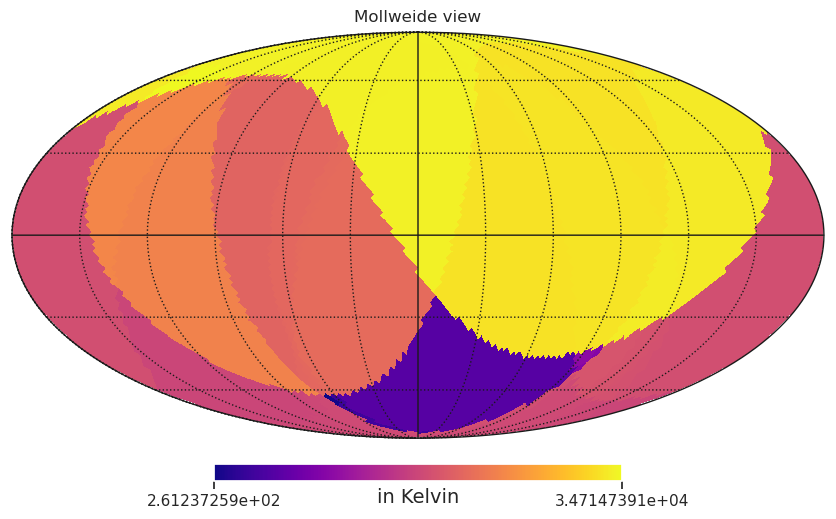

In [287]:
test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[2,:,150])] = power_output[2,:,225]
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",flip='geo',norm='log',format= '%.8e')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()

In [41]:
freq_range[110]

81.83999999999997

In [42]:
powercube_df=pd.DataFrame(power_output[0,:,:])
powercube_df.to_csv('/home/saurabhs/Documents/Yogen_starfire/RFInosynth_cubeLeo')

In [43]:
execution_time = end_time - start_time

print(f"Execution time: {execution_time} seconds")

Execution time: 7870.243119239807 seconds


## RFI power recieved in different orbits

## Polar orbit RFI waterfall plots

In [44]:
# Set time resolution
# Average velocity of satellite in LEO is ~8 km/s
time_res=10000
polat=np.linspace(-90,90,time_res)
polon=np.zeros(len(polat))
# Define trajectory pixels
pol_traj_pix=hp.ang2pix(nside,polon,polat,lonlat=True)


In [45]:
# waterfall plots of pixel vs frequency and power as the weight
x=freq_range
y=polat
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(pol_traj_pix),len(x)))
for i in range(len(x)):
    for index,j in enumerate(pol_traj_pix):
        power_val[index,i]+=power_output[0,j,i]


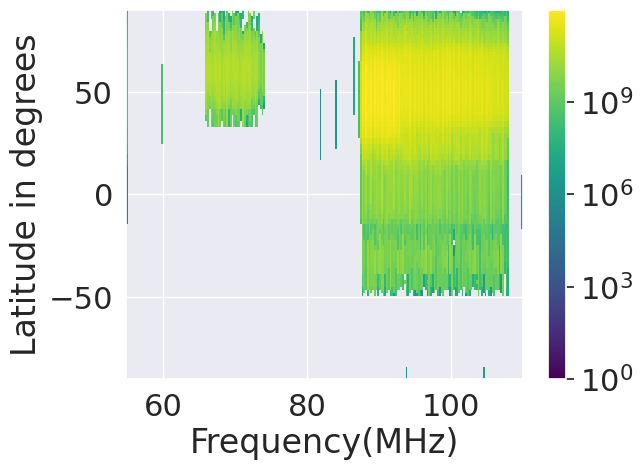

In [46]:
plt.pcolormesh(xx,yy,power_val,cmap='viridis',norm='log',vmin=1,rasterized=True)
plt.xlabel('Frequency(MHz)')
plt.ylabel('Latitude in degrees')
plt.colorbar()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_waterfall.pdf',dpi=600,bbox_inches='tight')
plt.show()

## Equatorial orbit RFI waterfall plots

In [47]:
# Set time resolution
# Average velocity of satellite in LEO is ~8 km/s
time_res=10000
eqlon=np.linspace(-180,180,time_res)
eqlat=np.zeros(len(eqlon))

# Define trajectory pixels
eq_traj_pix=hp.ang2pix(nside,eqlon,eqlat,lonlat=True)


In [48]:
# waterfall plots of pixel vs frequency and power as the weight
x=freq_range
y=eqlon
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(eq_traj_pix),len(x)))
for i in range(len(x)):
    for index,j in enumerate(eq_traj_pix):
        power_val[index,i]+=power_output[0,j,i]


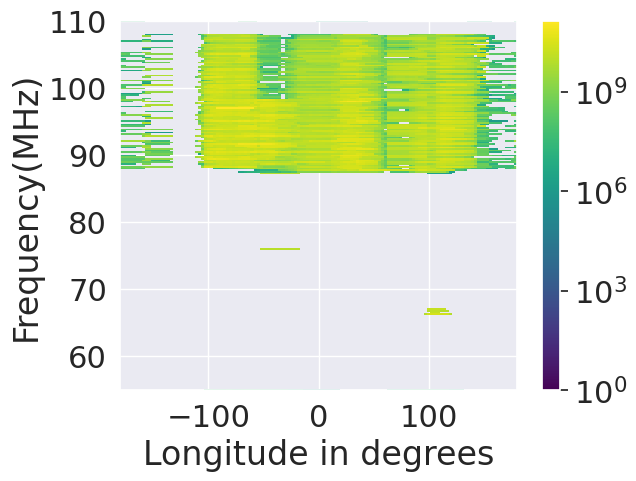

In [49]:
plt.pcolormesh(yy,xx,power_val,cmap='viridis',norm='log',vmin=1e0,rasterized=True)
plt.colorbar()
plt.xlabel('Longitude in degrees')
plt.ylabel('Frequency(MHz)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equisynth_waterfall_1.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [50]:
print(yy.shape,xx.shape,power_val.shape)

# plt.imshow(np.array([yy,xx,power_val]))

(10000, 226) (10000, 226) (10000, 226)


In [51]:
def shapecheck(lon,lat,name):
    checkpix=hp.ang2pix(nside,lon,lat,lonlat=True)
    checkmap=np.zeros(hp.nside2npix(nside))
    for pi in checkpix:
        checkmap[pi]+=1
    checkmap=np.where(checkmap != 0, 1, 0)
    return hp.mollview(checkmap,flip='geo',title=name,cmap='inferno')
    


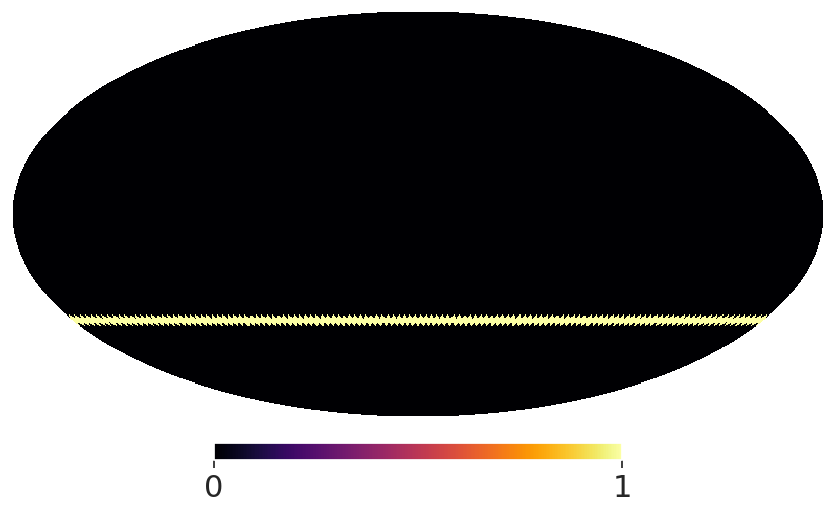

In [52]:
eqlat=np.full((np.shape(eqlon)),-40)

shapecheck(eqlon,eqlat,'')

## RFI freq summed power per pixel

### Polar orbit 

In [53]:
#GS for LEO
GS=np.zeros(len(freq_range))
for i in range(len(GS)):
    GS[i]+=np.mean(power_output[0,i,:])

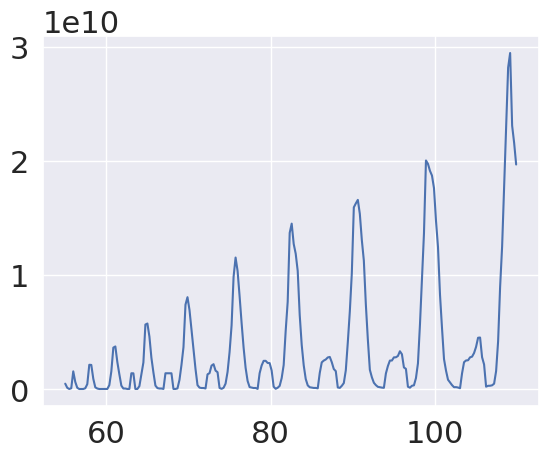

In [54]:
plt.plot(freq_range,GS)
plt.show()

In [56]:
fomdf=pd.DataFrame({'FOM':FOM_map})

In [57]:
# fomdf.to_csv('/home/saurabhs/Documents/Yogen_starfire/FOM_Nosynth.csv')